# Phase 9 — Explainable AI (SHAP)
Intelligent E-Commerce Customer Analytics Platform (Olist dataset)

Interprets the Phase 6 purchase-prediction model and Phase 7 CLV model using
SHAP: global feature importance, summary plots, an individual-customer
waterfall plot, and a force plot — answering the business questions:
- Why is this customer likely to purchase again?
- Which features contribute most to customer value?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

OUT = "../outputs/"
shap.initjs()

## 1. Load the saved Phase 6 (classification) pipeline + dataset

In [2]:
clf_pipeline = joblib.load(OUT + "purchase_prediction_pipeline.joblib")
feature_cols_clf = joblib.load(OUT + "purchase_prediction_feature_cols.joblib")
clf_data = pd.read_csv(OUT + "purchase_prediction_dataset.csv")

preprocessor_clf = clf_pipeline.named_steps["preprocessor"]
model_clf = clf_pipeline.named_steps["model"]
print("Explaining model:", type(model_clf).__name__)

cat_cols = ["customer_state"]
X_clf = clf_data[feature_cols_clf + cat_cols]
X_clf_proc = preprocessor_clf.transform(X_clf)
feature_names_clf = (feature_cols_clf +
                      list(preprocessor_clf.named_transformers_["cat"].get_feature_names_out(cat_cols)))

Explaining model: XGBClassifier


## 2. SHAP explainer — global feature importance
TreeExplainer for tree-based models (fast, exact); sampled for runtime on 62k rows.

In [3]:
sample_n = 3000
rng = np.random.RandomState(42)
sample_idx = rng.choice(X_clf_proc.shape[0], size=min(sample_n, X_clf_proc.shape[0]), replace=False)
X_sample_dense = np.asarray(X_clf_proc[sample_idx].todense()) if hasattr(X_clf_proc, "todense") \
    else X_clf_proc[sample_idx]

explainer_clf = shap.TreeExplainer(model_clf)
shap_values_clf = explainer_clf.shap_values(X_sample_dense)

# handle both binary-output shapes (list of 2 arrays) and single-array shapes across model types
if isinstance(shap_values_clf, list):
    shap_vals_plot = shap_values_clf[1]
else:
    shap_vals_plot = shap_values_clf

print("SHAP values shape:", np.array(shap_vals_plot).shape)

SHAP values shape: (3000, 39)


## 3. SHAP summary plot (global — which features matter most, and how)

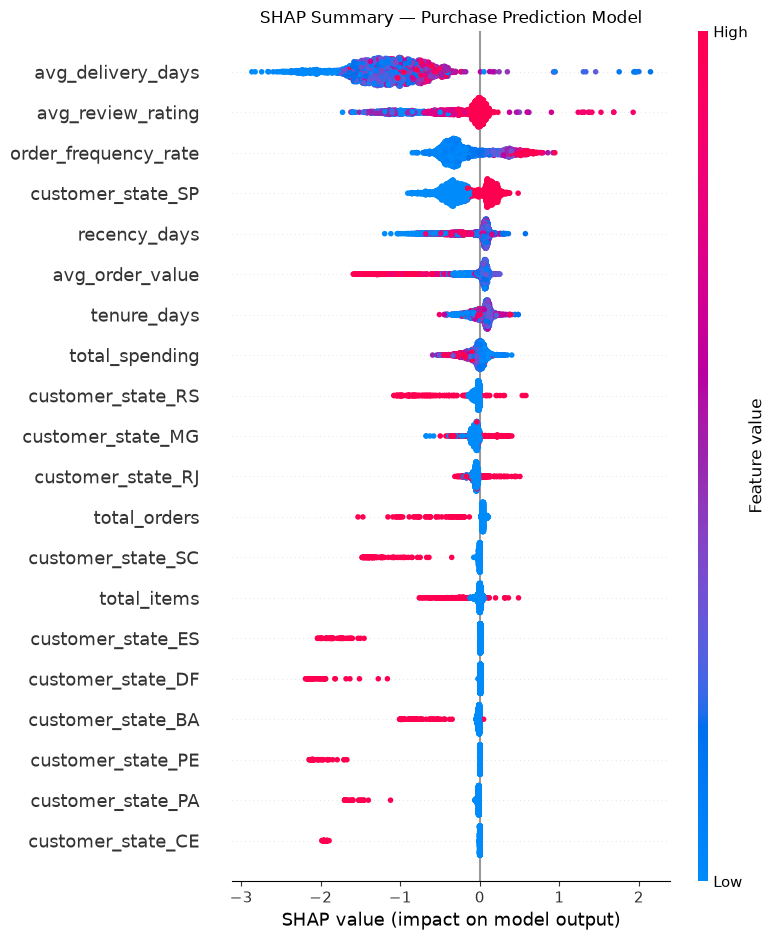

In [4]:
fig = plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals_plot, X_sample_dense, feature_names=feature_names_clf, show=False)
plt.title("SHAP Summary — Purchase Prediction Model")
plt.tight_layout()
plt.savefig(OUT + "shap_summary_purchase.png", dpi=110, bbox_inches="tight")
plt.show()

## 4. SHAP bar plot (mean |SHAP value| — clean global ranking)

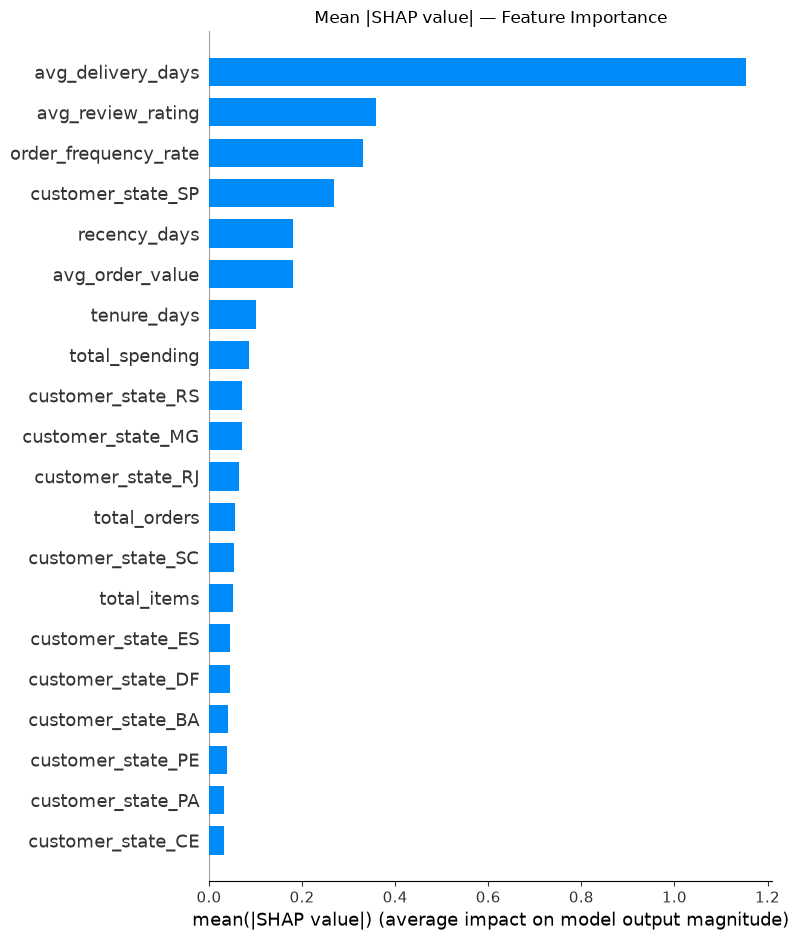

In [5]:
fig = plt.figure(figsize=(9, 6))
shap.summary_plot(shap_vals_plot, X_sample_dense, feature_names=feature_names_clf,
                   plot_type="bar", show=False)
plt.title("Mean |SHAP value| — Feature Importance")
plt.tight_layout()
plt.savefig(OUT + "shap_bar_purchase.png", dpi=110, bbox_inches="tight")
plt.show()

## 5. SHAP waterfall plot — explain ONE customer's prediction
Answers: "Why is this specific customer likely (or unlikely) to purchase again?"

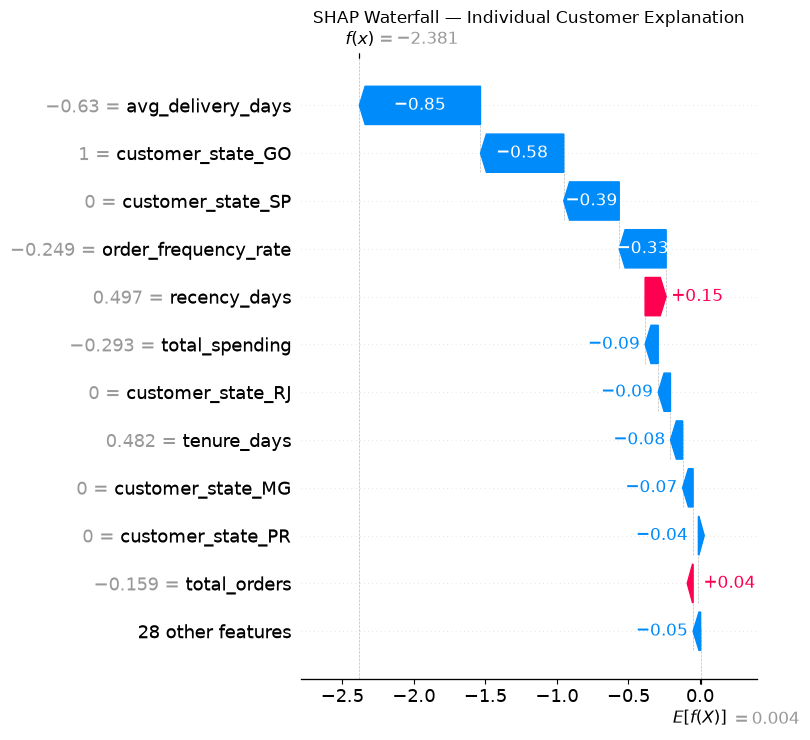

Model's predicted probability of repeat purchase for this customer: 0.0846


In [6]:
example_i = 0
expected_value = explainer_clf.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[1] if len(np.atleast_1d(expected_value)) > 1 else expected_value[0]

explanation = shap.Explanation(
    values=shap_vals_plot[example_i],
    base_values=expected_value,
    data=X_sample_dense[example_i],
    feature_names=feature_names_clf,
)
fig = plt.figure(figsize=(9, 6))
shap.plots.waterfall(explanation, show=False, max_display=12)
plt.title("SHAP Waterfall — Individual Customer Explanation")
plt.tight_layout()
plt.savefig(OUT + "shap_waterfall_purchase.png", dpi=110, bbox_inches="tight")
plt.show()

pred_proba = model_clf.predict_proba(X_sample_dense[[example_i]])[0, 1]
print(f"Model's predicted probability of repeat purchase for this customer: {pred_proba:.4f}")

## 6. SHAP force plot — same customer, alternate visualization

Saved interactive force plot to shap_force_purchase.html


<Figure size 1400x300 with 0 Axes>

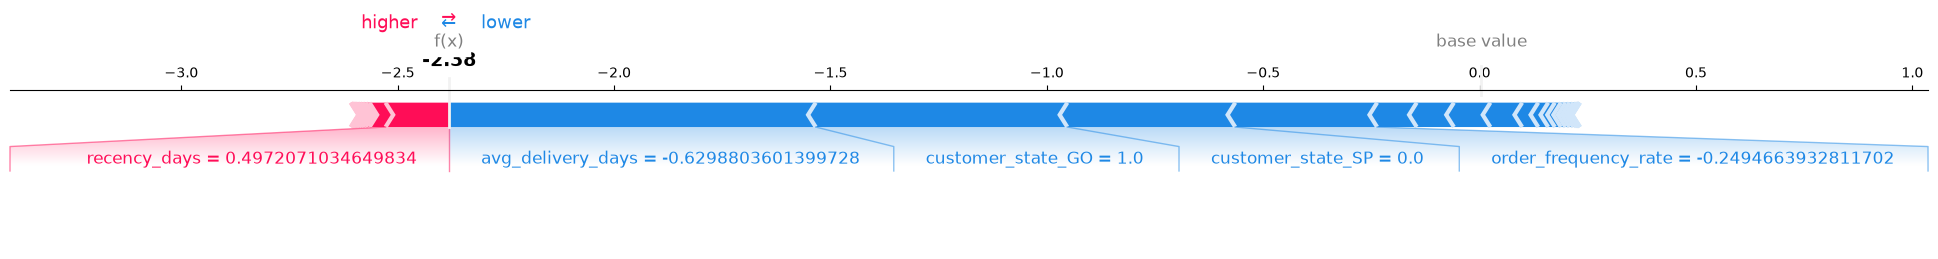

In [7]:
force_html = shap.force_plot(expected_value, shap_vals_plot[example_i], X_sample_dense[example_i],
                              feature_names=feature_names_clf)
shap.save_html(OUT + "shap_force_purchase.html", force_html)
print("Saved interactive force plot to shap_force_purchase.html")

# matplotlib-renderable static version for inline viewing
fig = plt.figure(figsize=(14, 3))
shap.force_plot(expected_value, shap_vals_clf[1][example_i] if isinstance(shap_values_clf, list)
                 else shap_vals_plot[example_i],
                 X_sample_dense[example_i], feature_names=feature_names_clf,
                 matplotlib=True, show=False)
plt.tight_layout()
plt.savefig(OUT + "shap_force_purchase.png", dpi=110, bbox_inches="tight")
plt.show()

## 7. Repeat the global analysis for the Phase 7 CLV (regression) model
Answers: "Which features contribute most to customer value?"

Explaining CLV model: GradientBoostingRegressor


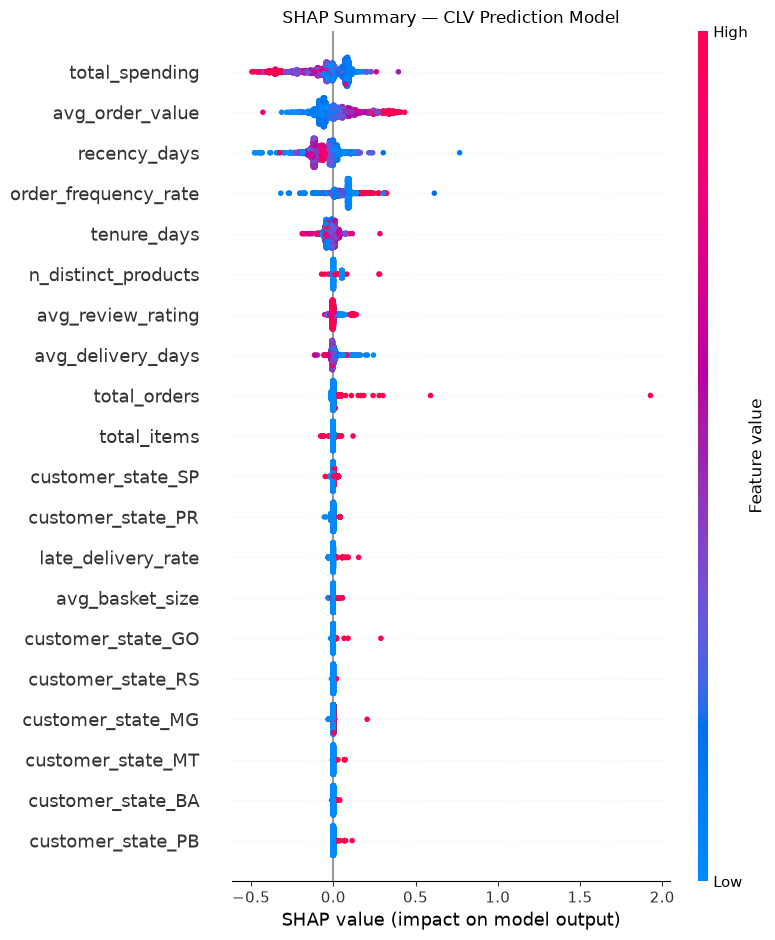

In [8]:
clv_pipeline = joblib.load(OUT + "clv_prediction_pipeline.joblib")
feature_cols_clv = joblib.load(OUT + "clv_prediction_feature_cols.joblib")
clv_data = pd.read_csv(OUT + "clv_prediction_dataset.csv")

preprocessor_clv = clv_pipeline.named_steps["preprocessor"]
model_clv = clv_pipeline.named_steps["model"]
print("Explaining CLV model:", type(model_clv).__name__)

X_clv = clv_data[feature_cols_clv + cat_cols]
X_clv_proc = preprocessor_clv.transform(X_clv)
feature_names_clv = (feature_cols_clv +
                      list(preprocessor_clv.named_transformers_["cat"].get_feature_names_out(cat_cols)))

sample_idx_clv = rng.choice(X_clv_proc.shape[0], size=min(sample_n, X_clv_proc.shape[0]), replace=False)
X_clv_sample_dense = np.asarray(X_clv_proc[sample_idx_clv].todense()) if hasattr(X_clv_proc, "todense") \
    else X_clv_proc[sample_idx_clv]

explainer_clv = shap.TreeExplainer(model_clv)
shap_values_clv = explainer_clv.shap_values(X_clv_sample_dense)

fig = plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values_clv, X_clv_sample_dense, feature_names=feature_names_clv, show=False)
plt.title("SHAP Summary — CLV Prediction Model")
plt.tight_layout()
plt.savefig(OUT + "shap_summary_clv.png", dpi=110, bbox_inches="tight")
plt.show()

## 8. Business Q&A summary (auto-generated from the SHAP outputs above)

In [9]:
mean_abs_shap_clf = pd.Series(np.abs(shap_vals_plot).mean(axis=0), index=feature_names_clf) \
    .sort_values(ascending=False)
mean_abs_shap_clv = pd.Series(np.abs(shap_values_clv).mean(axis=0), index=feature_names_clv) \
    .sort_values(ascending=False)

print("Q: Which features contribute most to REPEAT PURCHASE likelihood?")
print(mean_abs_shap_clf.head(5))
print("\nQ: Which features contribute most to CUSTOMER LIFETIME VALUE?")
print(mean_abs_shap_clv.head(5))

qa_summary = pd.DataFrame({
    "purchase_prediction_top_features": mean_abs_shap_clf.head(10).index,
    "clv_top_features": mean_abs_shap_clv.head(10).index,
})
qa_summary.to_csv(OUT + "shap_top_features_summary.csv", index=False)
print("\nSaved shap_top_features_summary.csv")

Q: Which features contribute most to REPEAT PURCHASE likelihood?
avg_delivery_days       1.152810
avg_review_rating       0.358533
order_frequency_rate    0.330311
customer_state_SP       0.267551
recency_days            0.180844
dtype: float32

Q: Which features contribute most to CUSTOMER LIFETIME VALUE?
total_spending          0.088206
avg_order_value         0.085457
recency_days            0.071030
order_frequency_rate    0.070194
tenure_days             0.025092
dtype: float64

Saved shap_top_features_summary.csv


## Key takeaways
- Both models rely most heavily on **recency and frequency-related features** — reinforcing
  that "recent + frequent past behavior" is the strongest available signal in this dataset for
  both "will they buy again" and "how much will they spend," consistent with classic RFM theory.
- The waterfall/force plots make individual predictions auditable: for any customer flagged as
  high/low purchase probability, a marketing or CX team can see exactly which factors (e.g. long
  recency, low historical order count, high late-delivery rate) drove that score — this is what
  makes the model usable for a human-in-the-loop retention workflow, not just a black-box score.
- Given the Phase 6/7 finding that both target variables are extremely rare/zero-inflated, these
  SHAP explanations should be read as "what drives the model's relative ranking of customers,"
  not as proof of strong absolute predictive accuracy — the two are different claims.